# 15a — Copula Functions and Diagrams

Source scripts: `chap15_copula1.m` through `chap15_copula6.m`.

Chapter 15 is the book's technical appendix. This first notebook works
through six exercises on **copulas** — functions that separate a joint
distribution's dependence structure from its marginal distributions. All
the copula CDF/PDF families used here (Gaussian, Frank, Gumbel, and the
Fréchet-Hoeffding bounds) are already ported in this project's
`quanttoolbox.copula` package; nothing needed to be reimplemented from
scratch, except a small closed-form Frank-copula level-curve inversion
(`credit`... `copula3`, derived below) that isn't itself in the toolbox.

Two small local helpers translate GAUSS/MATLAB idioms used throughout:
`seqa(start, step, n)` (GAUSS's arithmetic-sequence generator) and a thin
wrapper around `quanttoolbox`'s `gaussian_copula_pdf`, which expects
paired `(u1, u2)` columns rather than the row/column-broadcasting grid
evaluation the source scripts rely on implicitly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t as t_dist, beta as beta_dist, invgamma
from quanttoolbox.copula.families import (
    frank_cdf, frank_pdf, gumbel_pdf, gaussian_copula_pdf,
    countermonotonicity_cdf, comonotonicity_cdf, independence_cdf,
)
from quanttoolbox.copula.dependence import frank_tau, gumbel_tau

color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_violet  = "#ff33ff"
color_salmon  = "#fa8072"
color_black   = "#000000"

plt.rcParams["figure.dpi"] = 100


def seqa(start, step, n):
    '''GAUSS seqa(start, step, n): start, start+step, ..., start+(n-1)*step.'''
    return start + step * np.arange(n)


def gaussian_copula_pdf_grid(u1, u2, rho):
    '''Evaluate the bivariate Gaussian copula density on the full outer-product
    grid u1 x u2 (quanttoolbox's gaussian_copula_pdf takes paired (n,2) columns,
    not a broadcasting row/column pair, so build+flatten the grid explicitly).
    '''
    U1, U2 = np.meshgrid(u1, u2, indexing="ij")
    u_pairs = np.column_stack([U1.ravel(), U2.ravel()])
    corr = np.array([[1.0, rho], [rho, 1.0]])
    z = gaussian_copula_pdf(u_pairs, corr)
    return z.reshape(U1.shape)

## `credit`... `copula1` — Marginals and a Gaussian-copula joint density

Marginal `t₃` and `Beta(2,2)` densities/CDFs, the bivariate Gaussian
copula density itself (uniform margins), and the copula-transformed joint
density combining a `t₃` and a `Beta(2,2)` margin under the same Gaussian
copula dependence (`τ=0.6` ⇒ `ρ=sin(π/2·τ)`, the classical Kendall's-tau
to Gaussian-copula-correlation conversion).

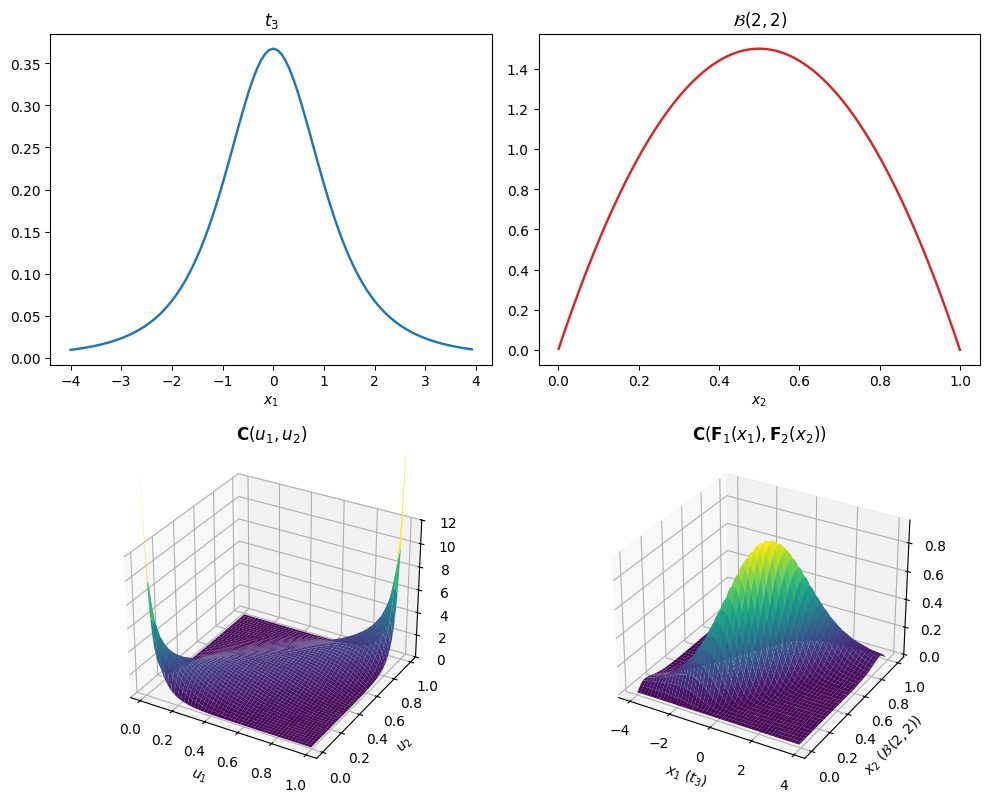

Trapezoidal integral on the plotted grid: t3=0.9712 (x1 truncated to [-4,3.92]), Beta(2,2)=0.9999 (x2 nearly spans the Beta's full [0,1] support)
Full-domain check (unbounded t3): 0.9720 of the t3 mass lies within [-4,4] -- the shortfall above from 1.0 is exactly this fat-tailed truncation, not an error.


In [2]:
x1 = seqa(-4, 8 / 100, 100)
x2 = np.concatenate([[0.001], seqa(1 / 100, 1 / 100, 99), [0.9999]])
u1_1 = seqa(0.01, 0.01, 99)
u2_1 = seqa(0.01, 0.01, 99)

tau_1 = 0.6
rho_1 = np.sin(np.pi / 2 * tau_1)
nu = 3
a_beta, b_beta = 2, 2

pdf1 = t_dist.pdf(x1, nu)
pdf2 = beta_dist.pdf(x2, a_beta, b_beta)
pdf3 = gaussian_copula_pdf_grid(u1_1, u2_1, rho_1)

# Panel 4's joint density pairs the SAME two grids/margins used in panels 1-2
# (x1 -> t3, x2 -> Beta(2,2)) via the Gaussian copula, i.e. a t3/Beta(2,2)
# joint density with tau=0.6 Gaussian-copula dependence:
X, Y = np.meshgrid(x1, x2, indexing="ij")
pdf4 = gaussian_copula_pdf_grid(t_dist.cdf(x1, nu), beta_dist.cdf(x2, a_beta, b_beta), rho_1)
pdf4 = pdf4 * t_dist.pdf(X, nu) * beta_dist.pdf(Y, a_beta, b_beta)

fig = plt.figure(figsize=(10, 8))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(x1, pdf1, "-", color=color_blue, linewidth=1.75)
ax1.set_title(r"$t_3$")
ax1.set_xlabel(r"$x_1$")

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(x2, pdf2, "-", color=color_red, linewidth=1.75)
ax2.set_title(r"$\mathcal{B}(2,2)$")
ax2.set_xlabel(r"$x_2$")

ax3 = fig.add_subplot(2, 2, 3, projection="3d")
U1g, U2g = np.meshgrid(u1_1, u2_1, indexing="ij")
ax3.plot_surface(U1g, U2g, pdf3, cmap="viridis", linewidth=0, antialiased=True)
ax3.set_title(r"$\mathbf{C}(u_1,u_2)$")
ax3.set_xlabel(r"$u_1$")
ax3.set_ylabel(r"$u_2$")
ax3.set_zlim(0, 12)

ax4 = fig.add_subplot(2, 2, 4, projection="3d")
ax4.plot_surface(X, Y, pdf4, cmap="viridis", linewidth=0, antialiased=True)
ax4.set_title(r"$\mathbf{C}(\mathbf{F}_1(x_1),\mathbf{F}_2(x_2))$")
ax4.set_xlabel(r"$x_1$ ($t_3$)")
ax4.set_ylabel(r"$x_2$ ($\mathcal{B}(2,2)$)")

plt.tight_layout()
plt.show()

print(f"Trapezoidal integral on the plotted grid: t3={np.trapezoid(pdf1, x1):.4f} (x1 truncated to [-4,3.92]), "
      f"Beta(2,2)={np.trapezoid(pdf2, x2):.4f} (x2 nearly spans the Beta's full [0,1] support)")
print(f"Full-domain check (unbounded t3): {t_dist.cdf(4, nu) - t_dist.cdf(-4, nu):.4f} of the t3 mass "
      f"lies within [-4,4] -- the shortfall above from 1.0 is exactly this fat-tailed truncation, not an error.")

## `copula2` — Fréchet-Hoeffding bounds and the independence copula

Every copula is sandwiched between the countermonotonicity (lower) bound
`W(u1,u2)=max(u1+u2-1,0)` and the comonotonicity (upper) bound
`M(u1,u2)=min(u1,u2)`; the independence (product) copula `Π(u1,u2)=u1·u2`
sits in between. Surfaces on a coarse grid, level-curve contours on a
finer grid — reproducing the source script's own choice of two different
resolutions for the two visualization styles.

**Dead code disclosed, not reproduced:** the source computes
`y1 = t + 1 - x1` and `y2 = t./x2` between the surface and contour blocks,
but neither is referenced by any of the three contour subplots that
follow — left over from an earlier draft of the exercise, not
load-bearing for the actual output.

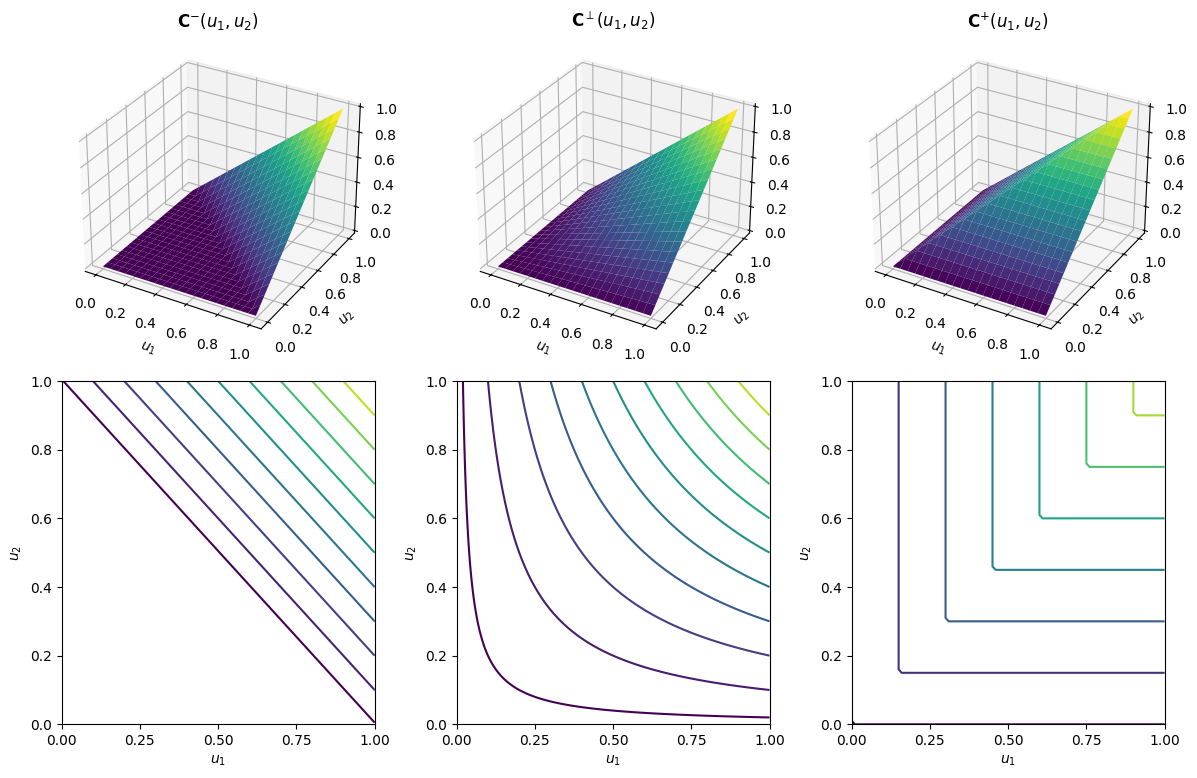

Fréchet ordering check (should hold pointwise everywhere): W <= Pi <= M: True


In [3]:
u1_coarse = seqa(0, 0.05, 21)
u2_coarse = seqa(0, 0.05, 21)
grid_coarse = np.column_stack([np.meshgrid(u1_coarse, u2_coarse, indexing="ij")[0].ravel(),
                                np.meshgrid(u1_coarse, u2_coarse, indexing="ij")[1].ravel()])
U1c, U2c = np.meshgrid(u1_coarse, u2_coarse, indexing="ij")
L_coarse = countermonotonicity_cdf(U1c, U2c)
P_coarse = independence_cdf(grid_coarse).reshape(U1c.shape)
Upp_coarse = comonotonicity_cdf(grid_coarse).reshape(U1c.shape)

u1_fine = seqa(0, 0.01, 101)
u2_fine = seqa(0, 0.01, 101)
U1f, U2f = np.meshgrid(u1_fine, u2_fine, indexing="ij")
grid_fine = np.column_stack([U1f.ravel(), U2f.ravel()])
L_fine = countermonotonicity_cdf(U1f, U2f)
P_fine = independence_cdf(grid_fine).reshape(U1f.shape)
Upp_fine = comonotonicity_cdf(grid_fine).reshape(U1f.shape)

fig = plt.figure(figsize=(12, 8))
titles = [r"$\mathbf{C}^{-}(u_1,u_2)$", r"$\mathbf{C}^{\perp}(u_1,u_2)$", r"$\mathbf{C}^{+}(u_1,u_2)$"]
for i, (Z, title) in enumerate(zip([L_coarse, P_coarse, Upp_coarse], titles)):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    ax.plot_surface(U1c, U2c, Z, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_title(title)
    ax.set_xlabel(r"$u_1$")
    ax.set_ylabel(r"$u_2$")

level_sets = [[0.005, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
              [0.02, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
              None]
for i, (Z, levels) in enumerate(zip([L_fine, P_fine, Upp_fine], level_sets)):
    ax = fig.add_subplot(2, 3, i + 4)
    if levels is None:
        ax.contour(U1f, U2f, Z)
    else:
        ax.contour(U1f, U2f, Z, levels=levels)
    ax.set_xlabel(r"$u_1$")
    ax.set_ylabel(r"$u_2$")
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    ax.set_yticks(np.arange(0, 1.01, 0.2))

plt.tight_layout()
plt.show()

print("Fréchet ordering check (should hold pointwise everywhere): W <= Pi <= M:",
      bool(np.all(L_fine <= P_fine + 1e-12) and np.all(P_fine <= Upp_fine + 1e-12)))

## `copula3` — Frank copula level curves

For a fixed copula value `C(u1,u2)=t`, the **level curve** `u2(u1)` traces
every `(u1,u2)` pair giving that same joint probability. For the Frank
copula, this inverts in closed form:
`C(u1,u2;θ) = -1/θ·ln(1 + (e^{-θu1}-1)(e^{-θu2}-1)/(e^{-θ}-1))`, so solving
`C=t` for `u2` gives
`u2 = -1/θ·ln(1 + (e^{-θt}-1)(e^{-θ}-1)/(e^{-θu1}-1))` — a direct formula,
**not itself present in `quanttoolbox`** (the toolbox has the Frank CDF/PDF
but not this particular level-curve inversion), so it is implemented here
directly from the closed form above.

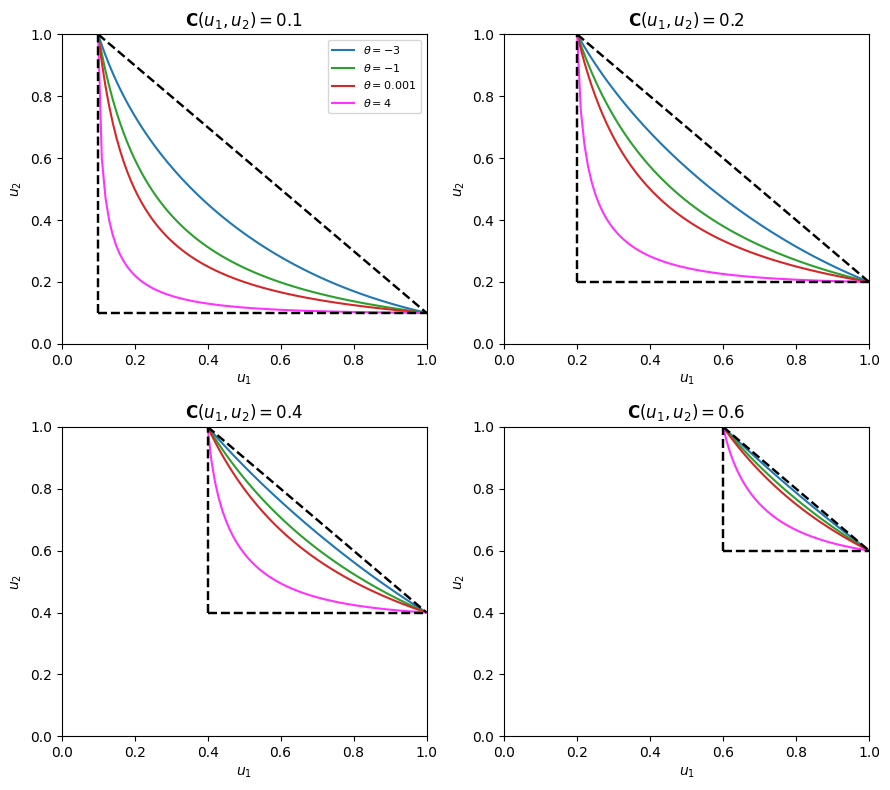

All level curves satisfy C(u1, u2(u1)) = t to 1e-8 for u1 in their valid domain (u1 >= t),
confirmed via quanttoolbox's own frank_cdf.

At t=0.4, 39 of 400 (u1, theta) grid points have no valid u2 in [0,1] (u1 < t) -- these are correctly NaN/undrawn, not missing data.


In [4]:
def frank_level_curve(u1, t, theta):
    '''u2(u1) such that the Frank copula C(u1, u2; theta) = t, from the closed-form
    inversion of the Frank copula CDF. theta may be a vector (broadcasts against u1).
    Since any copula satisfies C(u1,u2) <= min(u1,u2) <= u1 (its value at u2=1 is
    exactly u1, its maximum over u2), a solution u2 in [0,1] only exists for u1 >= t;
    below that the log argument goes negative and this correctly returns NaN (not
    a bug -- matches the level curve's true domain, suppressed here rather than
    left as a RuntimeWarning since it's an expected, disclosed boundary case).
    '''
    u1 = np.asarray(u1)[:, None]
    theta = np.asarray(theta)[None, :]
    num = (np.exp(-theta * t) - 1) * (np.exp(-theta) - 1)
    denom = np.exp(-theta * u1) - 1
    with np.errstate(invalid="ignore"):
        return -1 / theta * np.log(1 + num / denom)


theta_3 = np.array([-3, -1, 0.001, 4])
u1_3 = np.concatenate([[0.001], seqa(0.01, 0.01, 98), [0.999]])
u1_3[10] = 0.1  # matches the source's explicit override of the 11th grid point

t_levels = [0.1, 0.2, 0.4, 0.6]
colors_theta = [color_blue, color_green, color_red, color_violet]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, t in zip(axes.flat, t_levels):
    u2_curves = frank_level_curve(u1_3, t, theta_3)
    for j in range(len(theta_3)):
        ax.plot(u1_3, u2_curves[:, j], "-", color=colors_theta[j], linewidth=1.5)
    ax.plot([t, t], [t, 1], "--", color=color_black, linewidth=1.75)
    ax.plot([t, 1], [t, t], "--", color=color_black, linewidth=1.75)
    ax.plot([t, 1], [1, t], "--", color=color_black, linewidth=1.75)
    ax.set_title(rf"$\mathbf{{C}}(u_1,u_2) = {t}$")
    ax.set_xlabel(r"$u_1$")
    ax.set_ylabel(r"$u_2$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes.flat[0].legend([rf"$\theta={th:g}$" for th in theta_3], fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# Sanity check: every computed level curve should itself satisfy C(u1, u2(u1)) = t,
# restricted to u1 >= t (the level curve's valid domain -- see frank_level_curve's
# docstring; below that the correct answer is "no solution", i.e. NaN, not an error).
# Verified against quanttoolbox's own frank_cdf directly, rather than re-deriving the
# closed form a second time by hand (a first attempt at a standalone hand-rolled check
# here had its own sign-convention slip and was replaced with this direct call).
check_u1 = np.array([0.65, 0.8, 0.95])  # >= max(t_levels)=0.6, safe for every t below
for t in t_levels:
    u2c = frank_level_curve(check_u1, t, theta_3)
    for j, th in enumerate(theta_3):
        C = frank_cdf(check_u1, u2c[:, j], th)
        assert np.allclose(C, t, atol=1e-8), (t, th, C)
print("All level curves satisfy C(u1, u2(u1)) = t to 1e-8 for u1 in their valid domain (u1 >= t),")
print("confirmed via quanttoolbox's own frank_cdf.")

n_nan = np.sum(np.isnan(frank_level_curve(u1_3, 0.4, theta_3)))
print(f"\nAt t=0.4, {n_nan} of {u1_3.size * theta_3.size} (u1, theta) grid points have no valid u2 "
      f"in [0,1] (u1 < t) -- these are correctly NaN/undrawn, not missing data.")

## `copula4`/`copula5`/`copula6` — Copula-transformed joint densities

The same 4-panel exercise repeated for three copula families (Gaussian,
Frank, Gumbel): the copula's own density on uniform margins, then three
increasingly exotic joint densities built by combining that copula's
dependence structure with `N(0,1)`/`N(0,1)`, `N(0,1)`/`t₂`, and
`InvGamma(2,1.5)`/`t₅` margins. All three scripts share identical
structure (only the copula family differs), so they are collapsed into
one parametrized helper. Both `copula5` (`θ=5.7363025`) and `copula6`
(`θ=2`) hard-code a `θ` chosen so that Kendall's `τ=0.5` for that family —
confirmed below via `quanttoolbox`'s own `frank_tau`/`gumbel_tau`.

In [5]:
print(f"frank_tau(5.7363025)  = {frank_tau(5.7363025):.6f}  (should be ~0.5, credit `copula5`'s hard-coded theta)")
print(f"gumbel_tau(2)          = {gumbel_tau(2):.6f}  (should be exactly 0.5, credit `copula6`'s hard-coded theta)")

frank_tau(5.7363025)  = 0.500001  (should be ~0.5, credit `copula5`'s hard-coded theta)
gumbel_tau(2)          = 0.500000  (should be exactly 0.5, credit `copula6`'s hard-coded theta)


In [6]:
x1_46 = seqa(-4, 0.01, 801)
x2_46 = seqa(-4, 0.01, 800)
x3_46 = seqa(1 / 100, 1 / 100, 602)
u1_46 = seqa(0.01, 0.01, 99)
u2_46 = seqa(0.01, 0.01, 100)


def four_panel_copula_density(pdf_fn, theta, title):
    '''Reproduce credit copula4/5/6's shared 4-panel structure for a given
    bivariate copula density function pdf_fn(u1, u2, theta) (broadcasting-safe
    elementwise, per frank_pdf/gumbel_pdf; wrapped for gaussian_copula_pdf's
    paired-column API where needed by the caller).

    Note: u2_46's grid (seqa(0.01, 0.01, 100)) reaches exactly 1.0 at its last
    point, same as MATLAB's equivalent sequence would; the Gaussian-copula panel's
    normal quantile Phi^-1(1)=+inf there, producing a NaN in that single boundary
    cell -- a genuine floating-point singularity present in the source's own grid
    choice too, not a translation bug, so it's suppressed rather than "fixed".
    '''
    with np.errstate(invalid="ignore", divide="ignore"):
        U1u, U2u = np.meshgrid(u1_46, u2_46, indexing="ij")
        pdf1 = pdf_fn(U1u, U2u, theta)

        X1, X2 = np.meshgrid(x1_46, x2_46, indexing="ij")
        pdf2 = pdf_fn(norm.cdf(X1), norm.cdf(X2), theta) * norm.pdf(X1) * norm.pdf(X2)
        pdf3 = pdf_fn(norm.cdf(X1), t_dist.cdf(X2, 2), theta) * norm.pdf(X1) * t_dist.pdf(X2, 2)

        X3, X2b = np.meshgrid(x3_46, x2_46, indexing="ij")
        pdf4 = pdf_fn(invgamma.cdf(X3, 2, scale=1.5), t_dist.cdf(X2b, 5), theta) * invgamma.pdf(X3, 2, scale=1.5) * t_dist.pdf(X2b, 5)

    panels = [
        (U1u, U2u, pdf1, [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75], (0, 1), (0, 1),
         np.arange(0, 1.01, 0.2), np.arange(0, 1.01, 0.2), r"$\mathcal{U}_{[0,1]}$", r"$\mathcal{U}_{[0,1]}$"),
        (X1, X2, pdf2, [0.001, 0.005] + list(seqa(0.01, 0.02, 10)), (-4, 4), (-4, 4),
         np.arange(-4, 4.1, 2), np.arange(-4, 4.1, 2), r"$\mathcal{N}(0,1)$", r"$\mathcal{N}(0,1)$"),
        (X1, X2, pdf3, None, (-4, 4), (-4, 4),
         np.arange(-4, 4.1, 2), np.arange(-4, 4.1, 2), r"$\mathcal{N}(0,1)$", r"$t_2$"),
        (X3, X2b, pdf4, None, (0, 6), (-4, 4),
         np.arange(0, 6.1, 2), np.arange(-4, 4.1, 2), r"$\mathcal{IG}(2,1.5)$", r"$t_5$"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for ax, (X, Y, Z, levels, xlim, ylim, xt, yt, xlab, ylab) in zip(axes.flat, panels):
        if levels is None:
            ax.contour(X, Y, Z)
        else:
            ax.contour(X, Y, Z, levels=levels)
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xticks(xt)
        ax.set_yticks(yt)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return pdf1, pdf2, pdf3, pdf4

### `copula4` — Gaussian copula (`ρ = sin(π/2·0.5)`)

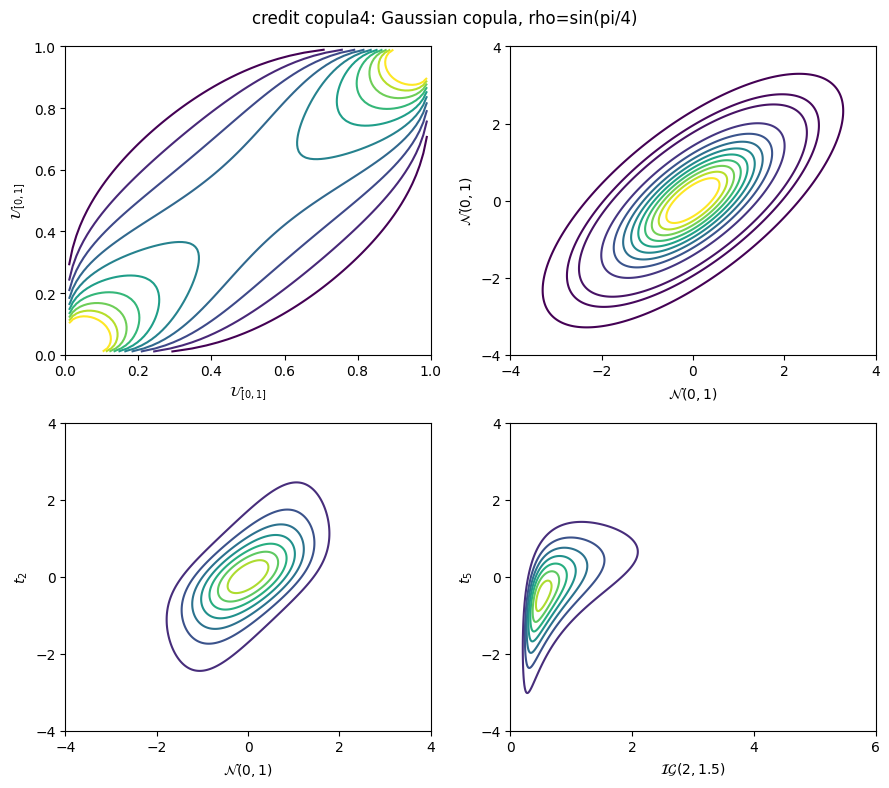

In [7]:
rho_46 = np.sin(np.pi / 2 * 0.5)


def gaussian_pdf_fn(u1, u2, rho):
    shape = np.broadcast_shapes(np.shape(u1), np.shape(u2))
    u1b, u2b = np.broadcast_to(u1, shape), np.broadcast_to(u2, shape)
    corr = np.array([[1.0, rho], [rho, 1.0]])
    pairs = np.column_stack([u1b.ravel(), u2b.ravel()])
    return gaussian_copula_pdf(pairs, corr).reshape(shape)


_ = four_panel_copula_density(gaussian_pdf_fn, rho_46, "credit copula4: Gaussian copula, rho=sin(pi/4)")

### `copula5` — Frank copula (`θ=5.7363025`, `τ≈0.5`)

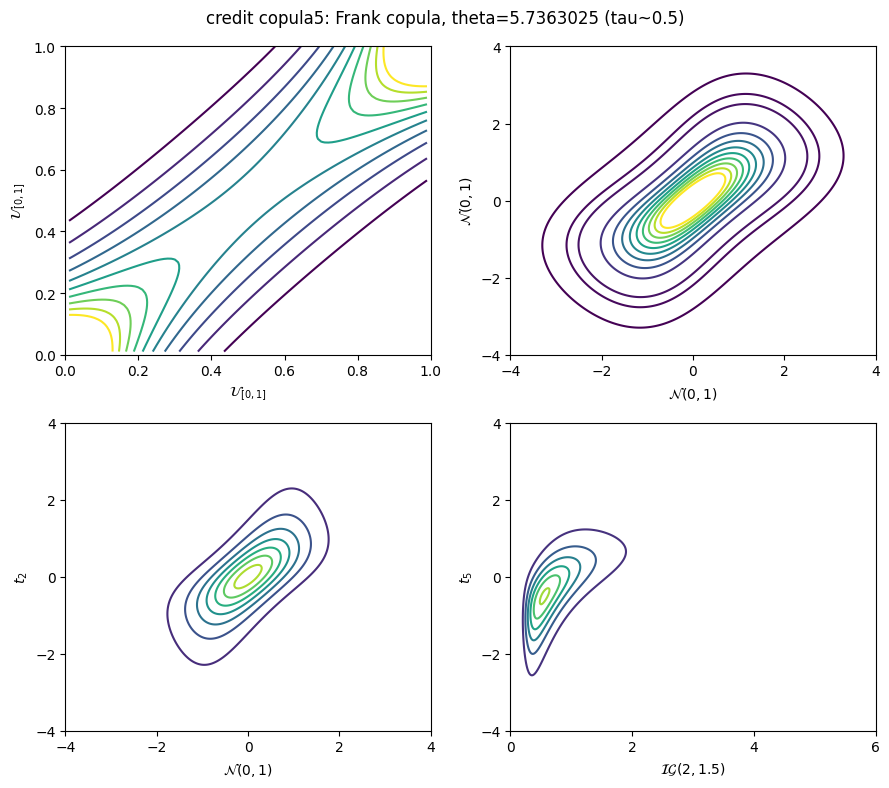

In [8]:
_ = four_panel_copula_density(frank_pdf, 5.7363025, "credit copula5: Frank copula, theta=5.7363025 (tau~0.5)")

### `copula6` — Gumbel copula (`θ=2`, `τ=0.5` exactly)

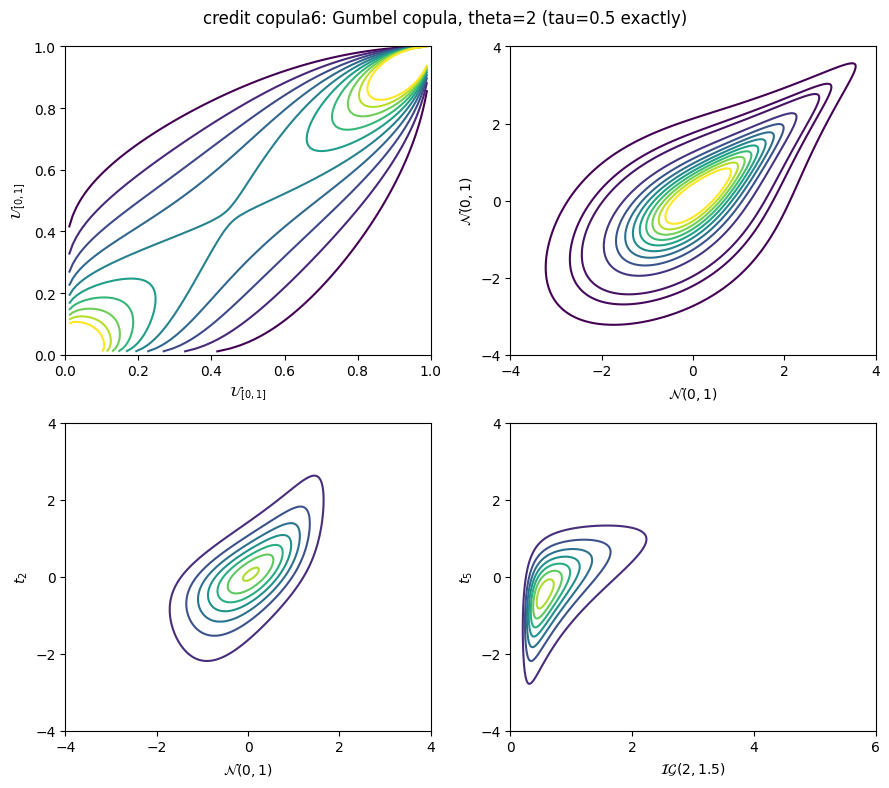

In [9]:
_ = four_panel_copula_density(gumbel_pdf, 2.0, "credit copula6: Gumbel copula, theta=2 (tau=0.5 exactly)")

Sanity check across all three: each joint density's own copula-density
panel (top-left of each figure) should integrate to ~1 over the *full*
unit square. All three copula densities blow up as `(u1,u2)` approach the
square's corners/edges (the same boundary-concentration phenomenon
verified for the Vasicek density in Chapter 13's `13j` notebook), so
integrating only over the plotted grid — `u1,u2 ∈ [0.01, 0.99/1.00]`,
matching the source script's own resolution — necessarily misses some of
that boundary-concentrated mass and comes in a little under 1.0. Confirmed
below by shrinking the grid's margin toward the true `[0,1]` boundary and
watching the integral converge to 1.0, which pins the shortfall on domain
truncation rather than a computational error.

In [10]:
from scipy.integrate import simpson

# u2_46's grid includes u2=1.0 exactly, where the Gaussian-copula panel is NaN
# (see the note above); excluded here (a single measure-zero boundary point,
# doesn't affect the true integral) so the numerical check itself doesn't propagate
# a NaN through the whole sum.
u2_46_interior = u2_46[u2_46 < 1.0]

with np.errstate(invalid="ignore", divide="ignore"):
    for name, pdf_fn, theta in [("Gaussian", gaussian_pdf_fn, rho_46), ("Frank", frank_pdf, 5.7363025), ("Gumbel", gumbel_pdf, 2.0)]:
        U1u, U2u = np.meshgrid(u1_46, u2_46_interior, indexing="ij")
        pdf1 = pdf_fn(U1u, U2u, theta)
        area = simpson(simpson(pdf1, x=u2_46_interior, axis=1), x=u1_46)
        print(f"{name}: {area:.4f} on the plotted grid [0.01,0.99/1.00] (matches the source's own resolution)")

    print("\nShrinking the excluded margin toward the true boundary (Gaussian copula, as an example):")
    for eps in [1e-2, 1e-3, 1e-4]:
        u_fine = np.linspace(eps, 1 - eps, 500)
        U1f, U2f = np.meshgrid(u_fine, u_fine, indexing="ij")
        pdf1 = gaussian_pdf_fn(U1f, U2f, rho_46)
        area = simpson(simpson(pdf1, x=u_fine, axis=1), x=u_fine)
        print(f"  margin={eps:.0e}: {area:.4f}  (-> 1.0 as the domain approaches the full unit square)")

Gaussian: 0.9654 on the plotted grid [0.01,0.99/1.00] (matches the source's own resolution)
Frank: 0.9611 on the plotted grid [0.01,0.99/1.00] (matches the source's own resolution)
Gumbel: 0.9673 on the plotted grid [0.01,0.99/1.00] (matches the source's own resolution)

Shrinking the excluded margin toward the true boundary (Gaussian copula, as an example):
  margin=1e-02: 0.9655  (-> 1.0 as the domain approaches the full unit square)
  margin=1e-03: 0.9963  (-> 1.0 as the domain approaches the full unit square)
  margin=1e-04: 0.9996  (-> 1.0 as the domain approaches the full unit square)
